# Interactive Sales Dashboard
## Week 6: Data Visualization with Seaborn & Plotly

This notebook walks you through creating an interactive sales dashboard step by step.

In [3]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style for better looking charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---

## Day 1: Seaborn Basics

Let's load our data and create some basic plots.

In [4]:
# Load the sales data
df = pd.read_csv('D:\\Things\\Documents\\Internship\\The Developer Arena\\Week 6\\sales_data.csv')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Show first few rows
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


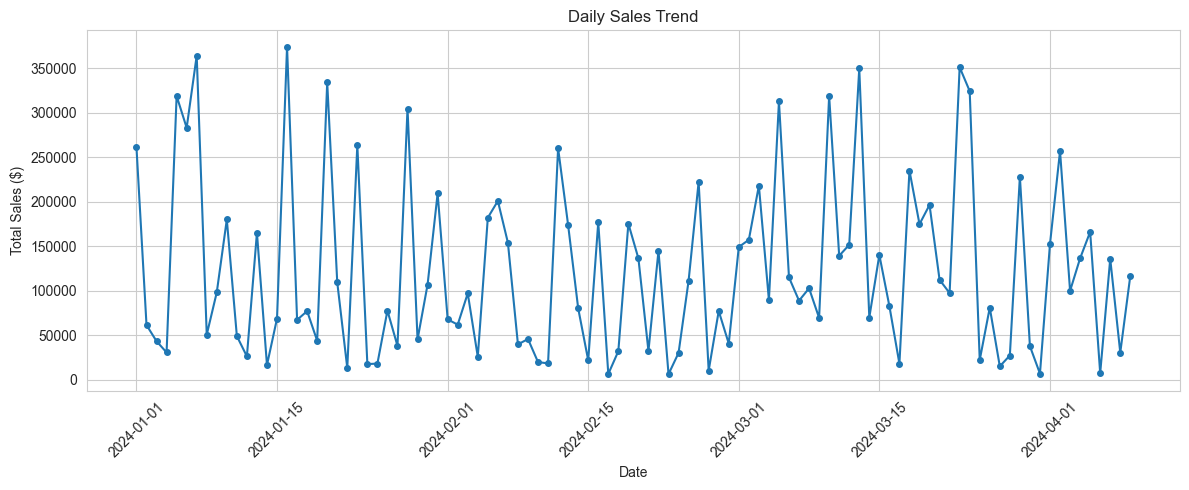

In [5]:
# Basic line chart - Sales over time
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Total_Sales'], marker='o', markersize=4)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Customizing Colors and Styles

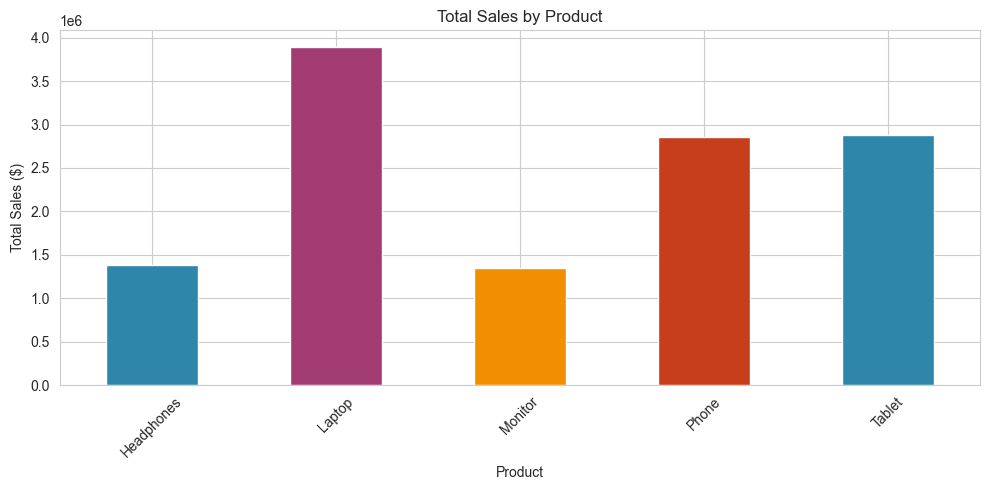

In [6]:
# Set custom color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
sns.set_palette(sns.color_palette(colors))

# Bar chart - Sales by product
plt.figure(figsize=(10, 5))
product_sales = df.groupby('Product')['Total_Sales'].sum()
product_sales.plot(kind='bar', color=colors)
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Day 2: Statistical Visualizations

Box plots and violin plots help us understand data distribution.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13504\3946312921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Price', data=df, palette='Set2')


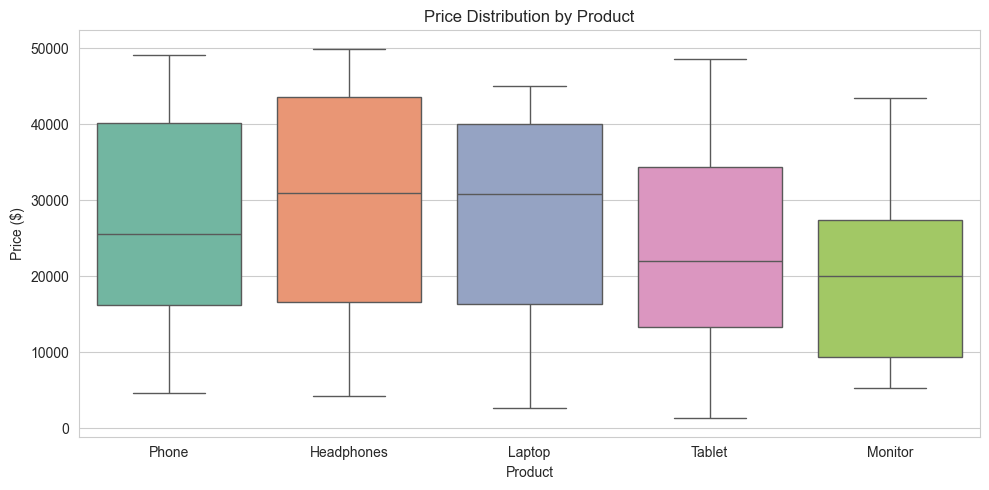

In [7]:
# Box Plot - Price distribution by product
plt.figure(figsize=(10, 5))
sns.boxplot(x='Product', y='Price', data=df, palette='Set2')
plt.title('Price Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13504\875514491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Product', y='Quantity', data=df, palette='Set3')


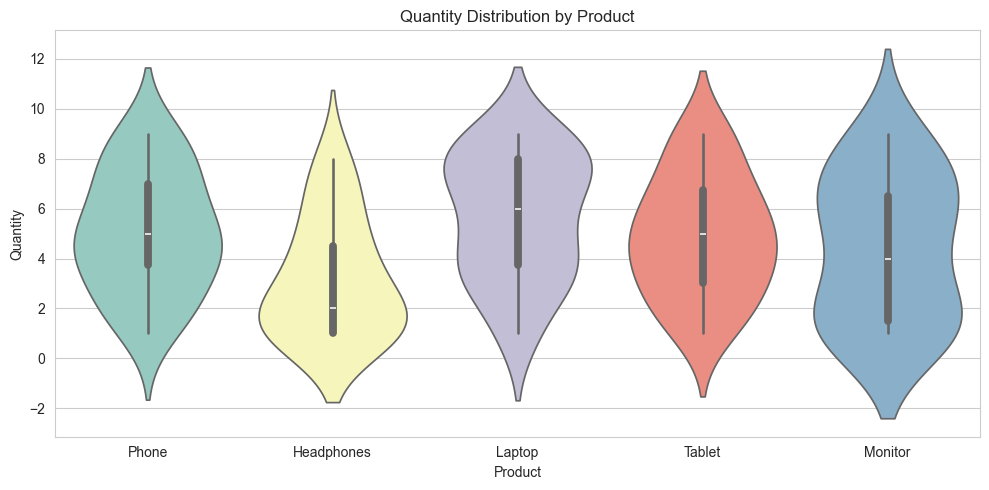

In [8]:
# Violin Plot - Quantity distribution by product
plt.figure(figsize=(10, 5))
sns.violinplot(x='Product', y='Quantity', data=df, palette='Set3')
plt.title('Quantity Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

---

## Day 3: Heatmaps & Correlation

Heatmaps show relationships between numerical variables.

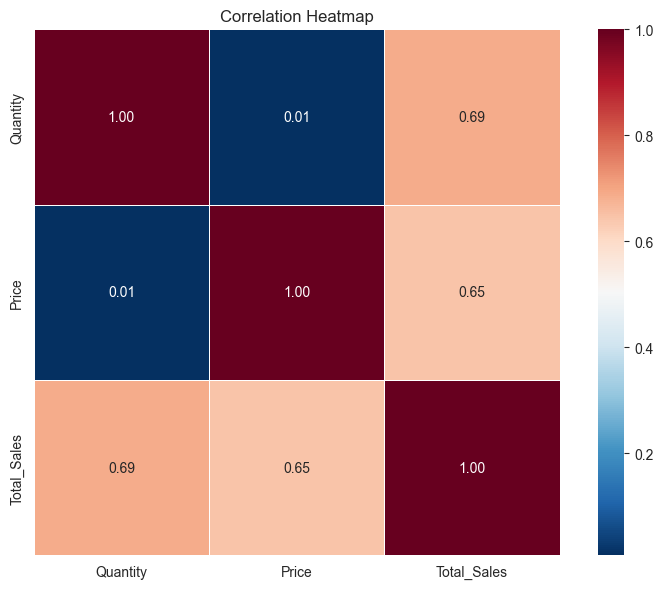


Correlation Values:
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


In [9]:
# Correlation matrix
numeric_cols = ['Quantity', 'Price', 'Total_Sales']
corr_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print correlation values
print('\nCorrelation Values:')
print(corr_matrix)

---

## Day 4: Multi-Plot Dashboards

Create a 2x2 grid with coordinated themes.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13504\3177866163.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Price', data=df, ax=axes[0, 1], palette='Set2')


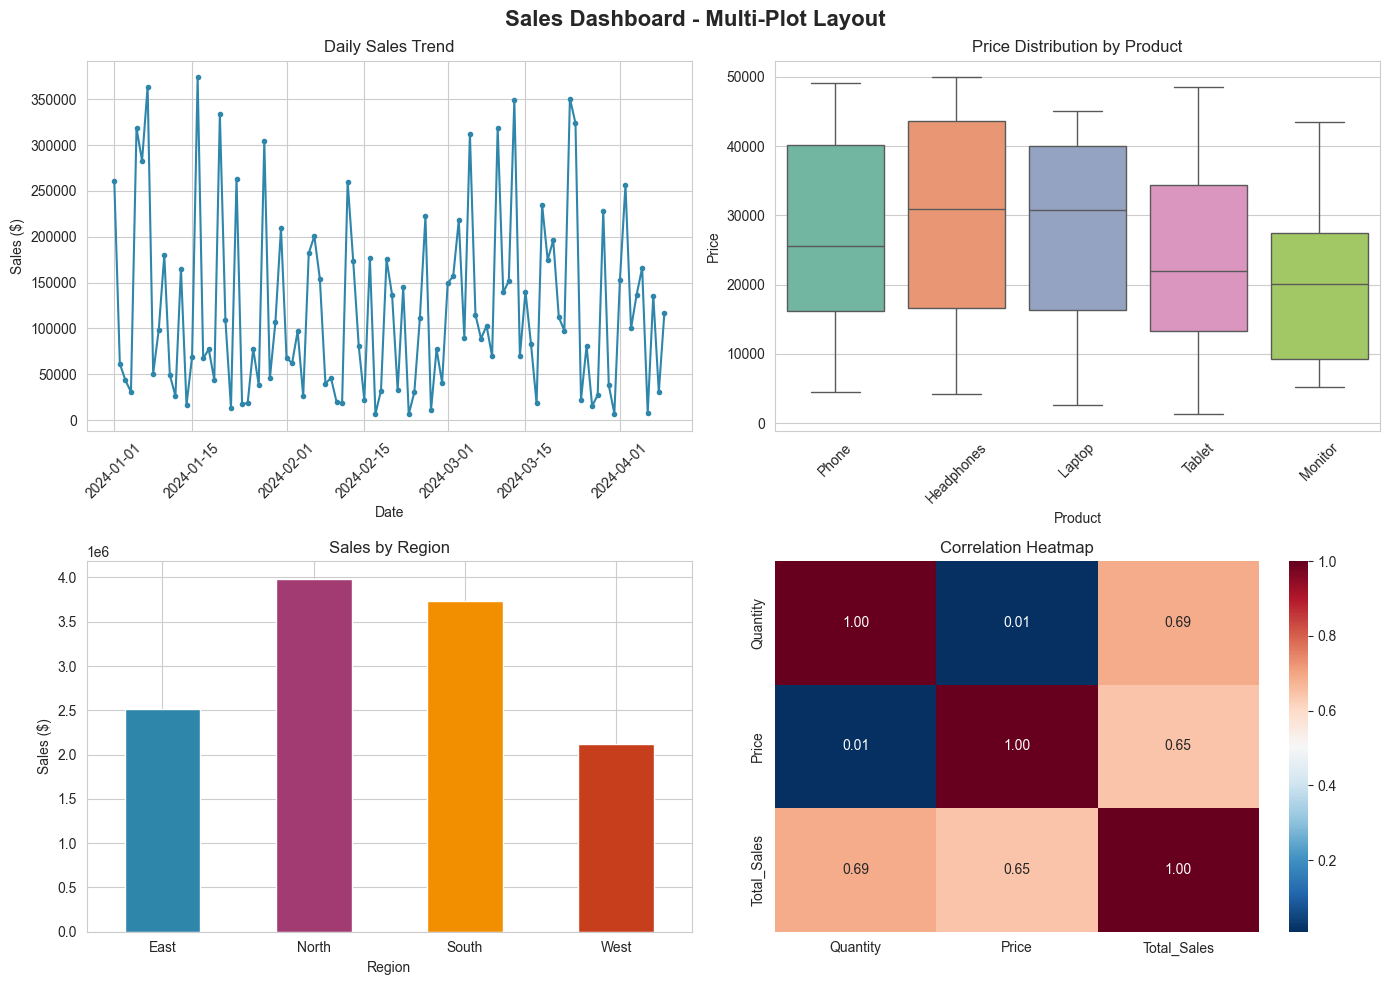

In [10]:
# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Dashboard - Multi-Plot Layout', fontsize=16, fontweight='bold')

# Subplot 1: Sales trend
axes[0, 0].plot(df['Date'], df['Total_Sales'], marker='o', color='#2E86AB', markersize=3)
axes[0, 0].set_title('Daily Sales Trend')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Subplot 2: Box plot
sns.boxplot(x='Product', y='Price', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Price Distribution by Product')
axes[0, 1].tick_params(axis='x', rotation=45)

# Subplot 3: Region sales
region_sales = df.groupby('Region')['Total_Sales'].sum()
region_sales.plot(kind='bar', ax=axes[1, 0], color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
axes[1, 0].set_title('Sales by Region')
axes[1, 0].set_xlabel('Region')
axes[1, 0].set_ylabel('Sales ($)')
axes[1, 0].tick_params(axis='x', rotation=0)

# Subplot 4: Correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', ax=axes[1, 1], fmt='.2f')
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

---

## Day 5: Interactive Visualizations with Plotly

Plotly creates interactive charts with hover effects.

In [11]:
# Interactive line chart with Plotly
fig = px.line(
    df, 
    x='Date', 
    y='Total_Sales',
    title='Interactive Sales Trend (Hover for details)',
    markers=True
)
fig.update_traces(line_color='#2E86AB', marker=dict(size=6))
fig.update_layout(template='plotly_white')
fig.show()

In [12]:
# Interactive box plot
fig = px.box(
    df,
    x='Product',
    y='Price',
    title='Price Distribution by Product',
    color='Product',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(template='plotly_white', showlegend=False)
fig.show()

In [13]:
# Interactive bar chart - Sales by Region
region_sales = df.groupby('Region')['Total_Sales'].sum().reset_index()

fig = px.bar(
    region_sales,
    x='Region',
    y='Total_Sales',
    title='Total Sales by Region',
    color='Region',
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(template='plotly_white', showlegend=False)
fig.show()

In [14]:
# Interactive pie chart - Product distribution
product_sales = df.groupby('Product')['Total_Sales'].sum().reset_index()

fig = px.pie(
    product_sales,
    values='Total_Sales',
    names='Product',
    title='Sales Distribution by Product',
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(template='plotly_white')
fig.show()

---

## Day 6: Dashboard Integration

Combine all visualizations into a cohesive dashboard layout.

In [15]:
# Create integrated dashboard with subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Daily Sales Trend', 'Price Distribution', 
                   'Sales by Region', 'Product Distribution'),
    specs=[[{'type': 'scatter'}, {'type': 'box'}],
           [{'type': 'bar'}, {'type': 'pie'}]]
)

# Add daily sales trend
fig.add_trace(
    go.Scatter(x=df['Date'], y=df['Total_Sales'], 
               mode='lines+markers', name='Sales',
               line=dict(color='#2E86AB', width=2)),
    row=1, col=1
)

# Add box plot
for product in df['Product'].unique():
    product_data = df[df['Product'] == product]
    fig.add_trace(
        go.Box(y=product_data['Price'], name=product),
        row=1, col=2
    )

# Add bar chart
fig.add_trace(
    go.Bar(x=region_sales['Region'], y=region_sales['Total_Sales'],
           marker_color='#A23B72', name='Region Sales'),
    row=2, col=1
)

# Add pie chart
fig.add_trace(
    go.Pie(labels=product_sales['Product'], 
           values=product_sales['Total_Sales'],
           hole=0.4, name='Product'),
    row=2, col=2
)

fig.update_layout(
    height=700,
    showlegend=False,
    title_text='Interactive Sales Dashboard',
    title_font_size=20
)

fig.show()

---

## Day 7: Save Visualizations

Save static charts and create the final presentation.

In [16]:
import os

# Create visualizations folder
os.makedirs('visualizations', exist_ok=True)

# Save static charts as PNG
# Chart 1: Sales trend
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df['Date'], df['Total_Sales'], marker='o', color='#2E86AB', markersize=4)
ax1.set_title('Daily Sales Trend')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/sales_trend.png', dpi=150)
plt.close()

# Chart 2: Box plot
fig2, ax2 = plt.subplots(figsize=(10, 5))
sns.boxplot(x='Product', y='Price', data=df, ax=ax2, palette='Set2')
ax2.set_title('Price Distribution by Product')
plt.tight_layout()
plt.savefig('visualizations/price_boxplot.png', dpi=150)
plt.close()

# Chart 3: Region sales
fig3, ax3 = plt.subplots(figsize=(10, 5))
region_sales.plot(kind='bar', ax=ax3, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
ax3.set_title('Total Sales by Region')
ax3.set_xlabel('Region')
ax3.set_ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('visualizations/region_sales.png', dpi=150)
plt.close()

# Chart 4: Correlation heatmap
fig4, ax4 = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', ax=ax4, fmt='.2f')
ax4.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png', dpi=150)
plt.close()

# Chart 5: Product pie chart
fig5, ax5 = plt.subplots(figsize=(8, 8))
product_sales.set_index('Product')['Total_Sales'].plot(
    kind='pie', ax=ax5, autopct='%1.1f%%', 
    colors=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6B4C9A']
)
ax5.set_title('Sales Distribution by Product')
ax5.set_ylabel('')
plt.tight_layout()
plt.savefig('visualizations/product_pie.png', dpi=150)
plt.close()

print('All visualizations saved to visualizations/ folder')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13504\544628173.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Price', data=df, ax=ax2, palette='Set2')


All visualizations saved to visualizations/ folder


---

## Summary

This dashboard includes:

1. **Line Chart** - Daily sales trend over time
2. **Box Plot** - Price distribution by product category
3. **Bar Chart** - Total sales by region
4. **Violin Plot** - Quantity distribution by product
5. **Heatmap** - Correlation between numerical variables
6. **Pie Chart** - Sales distribution by product